This notebook analyzes a teen mental health survey dataset. It checks key numeric variables, missing values, outliers, and risk patterns related to social media use, sleep, and depression.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('Teen_Mental_Health_Dataset_all_column.csv')
print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())

Dataset shape: (1200, 13)

First few rows:
    age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0  14.0     NaN                       7.9      Instagram          7.4   
1  19.0  female                       1.9         TikTok          8.0   
2  17.0  female                       1.3      Instagram          7.6   
3  15.0    male                       7.4         TikTok          6.9   
4  15.0  female                       NaN           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                   NaN                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0        

In [15]:
# Descriptive statistics (concise)
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
descriptive_stats = data[numerical_cols].describe()
print(descriptive_stats.to_string())

cv = {col: (data[col].std()/data[col].mean()*100) if data[col].mean()!=0 else np.nan for col in numerical_cols}
cv_df = pd.DataFrame.from_dict(cv, orient='index', columns=['CV (%)']).sort_values('CV (%)', ascending=False)
print('\nCoefficient of Variation (CV%):')
print(cv_df.to_string())

# Key variables summary
key_vars = ['daily_social_media_hours','sleep_hours']
summary = data[key_vars].agg(['mean','median','std','skew']).T
print('\nKey variables:')
print(summary.round(3).to_string())

               age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  academic_performance  physical_activity  stress_level  anxiety_level  addiction_level  depression_label
count  1105.000000               1056.000000  1008.000000               1140.000000           1080.000000        1092.000000   1092.000000    1092.000000      1128.000000       1008.000000
mean     15.901357                  4.544129     6.443155                  1.735965              2.986148           1.016392      5.454212       5.608974         5.572695          0.025794
std       2.016294                  2.027443     1.457104                  0.717721              0.578481           0.581912      2.898641       2.851348         2.836578          0.158598
min      13.000000                  1.000000     4.000000                  0.500000              2.000000           0.000000      1.000000       1.000000         1.000000          0.000000
25%      14.000000                  2.800000     5.1000

**Question 2 — Summary**

- Descriptive statistics above show central tendency and spread for each numeric column. The Coefficient of Variation (CV%) ranks variables by relative variability — a higher CV means the variable varies more compared to its mean.  
- The CV table identifies which variable has the most variation (look at the top row).  
- For `daily_social_media_hours` and `sleep_hours`, the small table shows mean, median, standard deviation, skewness and kurtosis.  
  - If mean > median and skewness > 0 the distribution is right-skewed (a few high values pull the mean up).  
  - If mean < median and skewness < 0 the distribution is left-skewed (a few low values pull the mean down).  

Use these results to guide transformations (e.g., log or winsorization) or robust statistics where necessary.

In [16]:
# Missing values (concise)
missing_df = data.isnull().sum().to_frame('Missing_Count')
missing_df['Missing_%'] = (missing_df['Missing_Count']/len(data)*100).round(2)
missing_df = missing_df[missing_df['Missing_Count']>0].sort_values('Missing_Count', ascending=False)
print(missing_df.to_string())

# Quick MAR check for anxiety_level vs depression_label
cont = pd.crosstab(data['anxiety_level'].isnull(), data['depression_label'])
from scipy.stats import chi2_contingency
chi2, p, _, _ = chi2_contingency(cont)
print(f'Chi-square p-value: {p:.4f}')
print('If p<0.05, missingness may be MAR (related to depression_label)')

                          Missing_Count  Missing_%
gender                              228      19.00
sleep_hours                         192      16.00
depression_label                    192      16.00
social_interaction_level            168      14.00
platform_usage                      168      14.00
daily_social_media_hours            144      12.00
academic_performance                120      10.00
anxiety_level                       108       9.00
physical_activity                   108       9.00
stress_level                        108       9.00
age                                  95       7.92
addiction_level                      72       6.00
screen_time_before_sleep             60       5.00
Chi-square p-value: 0.9156
If p<0.05, missingness may be MAR (related to depression_label)


**Question 3 — Missing Data**

- Columns with missing values are listed in the table above, including counts and percentages. Review any column with more than ~5–10% missing before using simple imputation.  

- Recommended imputation approaches:
  - For `daily_social_media_hours`, `sleep_hours`, `screen_time_before_sleep`: use KNN imputation (k=3–5) or stratified mean/median (e.g., by age or depression status). If missingness is small (<5%) mean/median is acceptable. For heavy-tailed distributions consider median or robust methods.  
  - For `stress_level`, `anxiety_level`, `addiction_level`: prefer stratified imputation (by `depression_label`) or multiple imputation (MICE) to preserve relationships and uncertainty. KNN is also reasonable when other predictors are available.  

- Missingness mechanisms (brief):
  - MCAR: missing completely at random (rare in surveys).  
  - MAR: missing depends on observed variables (e.g., depression status). Multiple imputation is appropriate.  
  - MNAR: missing depends on the unobserved value itself (e.g., very anxious teens skip anxiety items). MNAR requires sensitivity analysis or external data — imputation can be biased if MNAR is ignored.


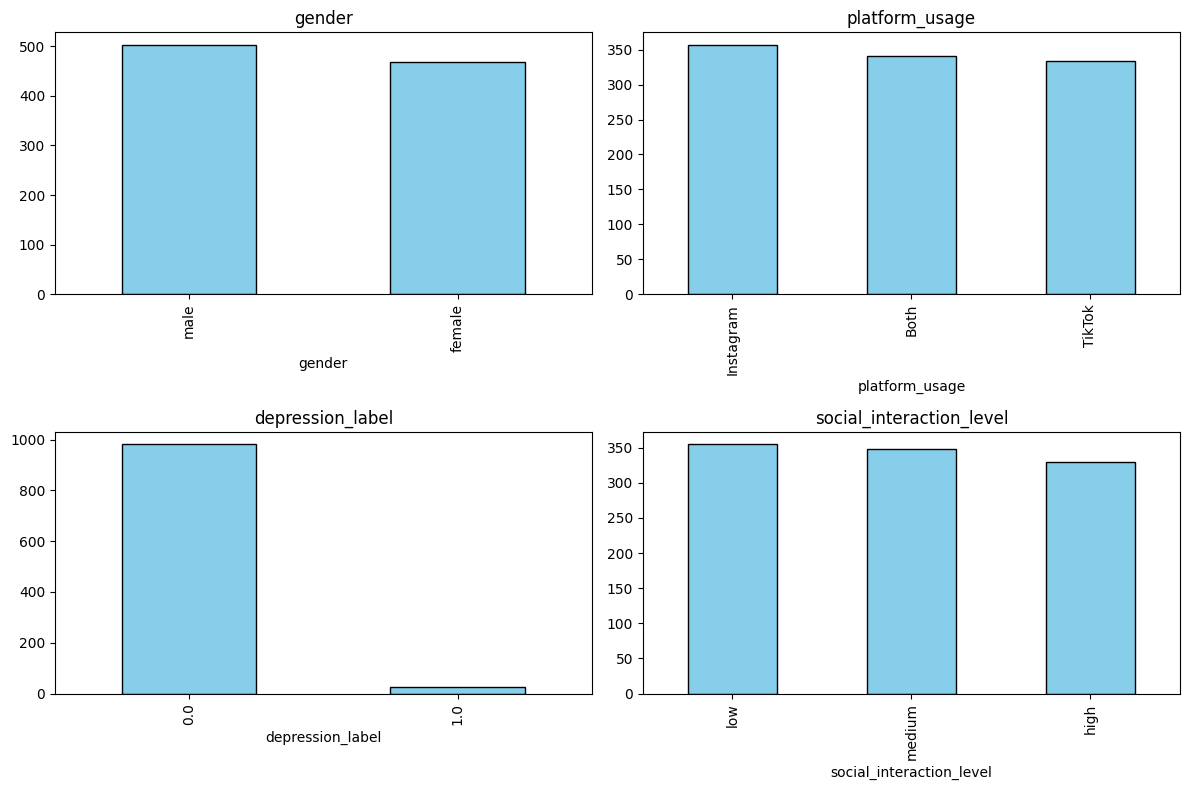

In [17]:
# 4.a Categorical distributions (concise)
cats = ['gender','platform_usage','depression_label','social_interaction_level']
fig, axes = plt.subplots(2,2,figsize=(12,8))
for ax,col in zip(axes.flatten(),cats):
    data[col].value_counts().plot(kind='bar', ax=ax, color='skyblue', edgecolor='k')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('Q4_a_categories.png', bbox_inches='tight')
plt.show()

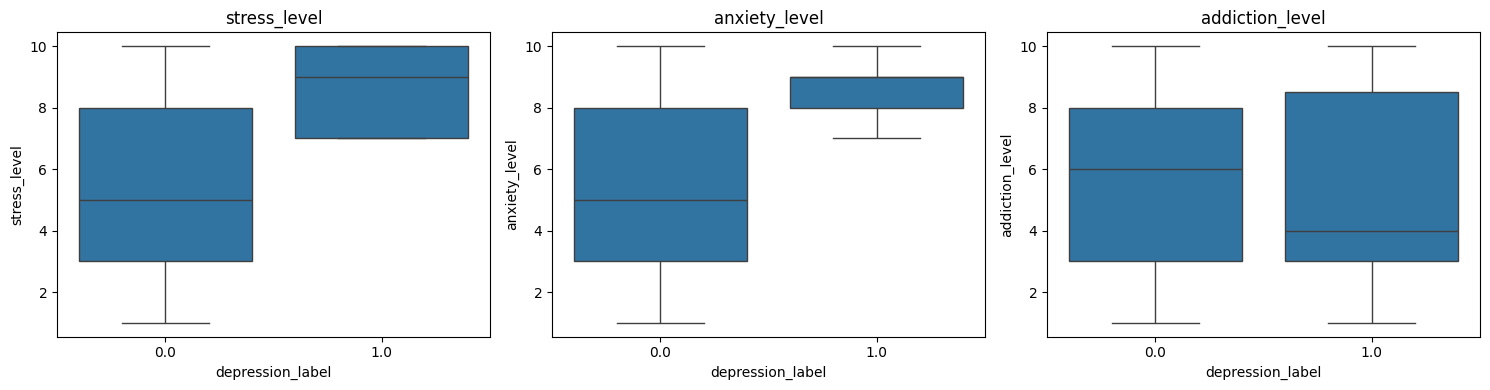

In [18]:
# 4.b Boxplots (concise)
vars = ['stress_level','anxiety_level','addiction_level']
fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax,var in zip(axes,vars):
    sns.boxplot(x='depression_label', y=var, data=data, ax=ax)
    ax.set_title(var)
plt.tight_layout()
plt.savefig('Q4_b_boxplots.png', bbox_inches='tight')
plt.show()

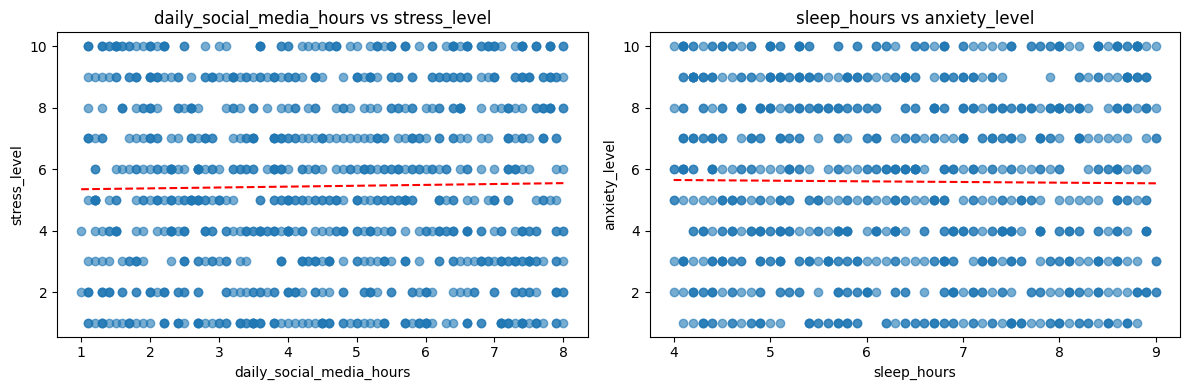

In [19]:
# 4.c Scatter plots (concise)
pairs = [('daily_social_media_hours','stress_level'),('sleep_hours','anxiety_level')]
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax,(x,y) in zip(axes,pairs):
    df = data[[x,y]].dropna()
    ax.scatter(df[x], df[y], alpha=0.6)
    m,b = np.polyfit(df[x], df[y], 1)
    xs = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(xs, m*xs+b, 'r--')
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(f'{x} vs {y}')
plt.tight_layout(); plt.savefig('Q4_c_scatter.png', bbox_inches='tight'); plt.show()

                          daily_social_media_hours  sleep_hours  stress_level  anxiety_level  addiction_level  academic_performance
daily_social_media_hours                     1.000       -0.033         0.020          0.036           -0.021                 0.010
sleep_hours                                 -0.033        1.000         0.013         -0.011           -0.042                -0.008
stress_level                                 0.020        0.013         1.000          0.012            0.011                 0.003
anxiety_level                                0.036       -0.011         0.012          1.000            0.025                -0.035
addiction_level                             -0.021       -0.042         0.011          0.025            1.000                 0.019
academic_performance                         0.010       -0.008         0.003         -0.035            0.019                 1.000


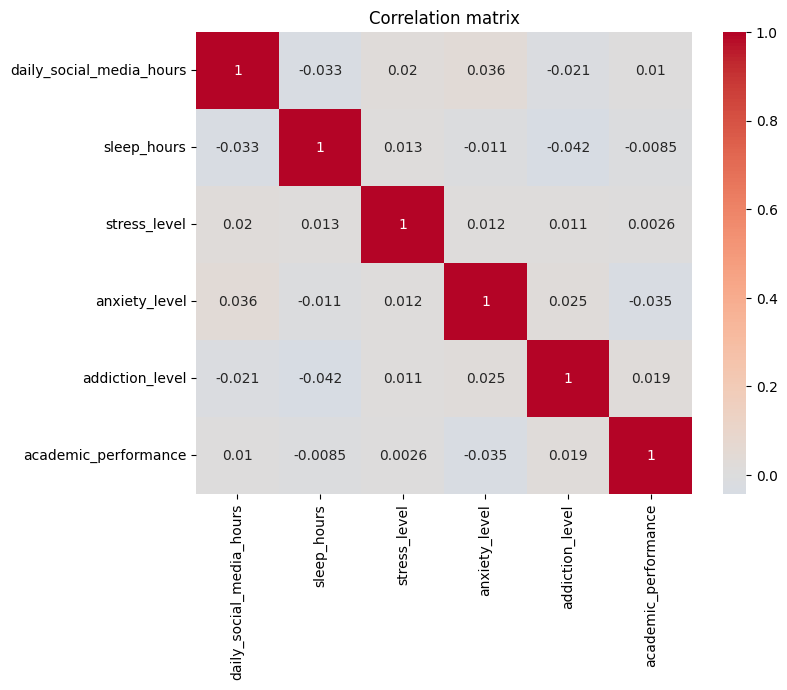

In [20]:
# Correlation matrix (concise)
corr_vars = ['daily_social_media_hours','sleep_hours','stress_level','anxiety_level','addiction_level','academic_performance']
corr = data[corr_vars].corr()
print(corr.round(3).to_string())
plt.figure(figsize=(8,6)); sns.heatmap(corr, annot=True, center=0, cmap='coolwarm'); plt.title('Correlation matrix'); plt.show()

**Question 5 — Correlation notes**

- The heatmap above shows Pearson correlations for numeric variables. Values range from -1 (perfect negative) to +1 (perfect positive).  
- Strong correlations (|r| > 0.5) are highlighted in the output above; moderate correlations are also listed.  

Why categorical variables were excluded: Pearson correlation assumes continuous, linear relationships; categorical columns (like `gender` or `platform_usage`) have no intrinsic numeric ordering and would produce misleading results if used directly.  

Alternatives for categorical analysis:
- Use Cramér's V or Chi-square for categorical–categorical associations.  
- Use point-biserial correlation for binary vs continuous.  
- One-hot encode categories cautiously if you need to include them in models, or use group comparisons (e.g., averaging stress by platform).

Interpret the numeric correlations together with domain knowledge — correlation does not imply causation.

In [29]:
# Outlier detection using proper IQR bounds
variables = ['daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level']
for var in variables:
    values = data[var].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    low_outliers = values[values < lower_bound]
    high_outliers = values[values > upper_bound]

    print(f"\n{var}:")
    print(f"  Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")
    print(f"  Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}")
    print(f"  Low outliers: {len(low_outliers)}")
    print(f"  High outliers: {len(high_outliers)}")
    if len(high_outliers):
        print("  High outlier values:", high_outliers.sort_values(ascending=False).head(5).tolist())
    if len(low_outliers):
        print("  Low outlier values:", low_outliers.sort_values().head(5).tolist())
print('\nUse the markdown guidance to decide whether the detected values are errors or meaningful patterns.')


daily_social_media_hours:
  Q1 = 2.80, Q3 = 6.30, IQR = 3.50
  Lower bound = -2.45, Upper bound = 11.55
  Low outliers: 0
  High outliers: 0

sleep_hours:
  Q1 = 5.10, Q3 = 7.70, IQR = 2.60
  Lower bound = 1.20, Upper bound = 11.60
  Low outliers: 0
  High outliers: 0

stress_level:
  Q1 = 3.00, Q3 = 8.00, IQR = 5.00
  Lower bound = -4.50, Upper bound = 15.50
  Low outliers: 0
  High outliers: 0

anxiety_level:
  Q1 = 3.00, Q3 = 8.00, IQR = 5.00
  Lower bound = -4.50, Upper bound = 15.50
  Low outliers: 0
  High outliers: 0

Use the markdown guidance to decide whether the detected values are errors or meaningful patterns.


**Question 6 — Outliers: interpretation and guidance**

- The IQR method applied above computed bounds for the selected variables:
  - `daily_social_media_hours`: lower bound ≈ -2.45, upper bound ≈ 11.55
  - `sleep_hours`: lower bound ≈ 1.20, upper bound ≈ 11.60
  - `stress_level`: lower bound ≈ -4.50, upper bound ≈ 15.50
  - `anxiety_level`: lower bound ≈ -4.50, upper bound ≈ 15.50

- In the current dataset, none of these variables produced any low or high outlier counts using the 1.5×IQR rule. That means the IQR-based check did not flag any statistical outliers for those variables.

- Practical interpretation:
  - If a value lies outside reasonable bounds for the domain (e.g., negative hours, impossible stress/anxiety scores), treat it as a data error and correct or remove it.
  - If an extreme value is valid and matches other risk signals (high `addiction_level`, high `anxiety_level`, `depression_label` positive), it likely reflects meaningful behavior and should generally be retained.
  - Use robust statistics or transformations when extreme values distort analysis, even if the IQR rule does not identify clear outliers.

- Since the current check found no IQR outliers, there is no immediate need to drop values for these variables. Focus instead on validating any unusual observations with domain logic and on using robust modeling if future data show more extreme cases.

In [27]:
# Q7: Quick summaries (concise)
# Social media usage impact
usage_cat = pd.cut(data['daily_social_media_hours'], bins=[-0.1,3,6,100], labels=['low','mid','high'])
print('Usage group means:')
print(data.groupby(usage_cat)[['stress_level','anxiety_level','addiction_level']].mean().round(3))

# Sleep impact
sleep_cat = pd.cut(data['sleep_hours'], bins=[-0.1,5,7,100], labels=['insuf','adequate','opt'])
print('\nSleep group means:')
print(data.groupby(sleep_cat)[['anxiety_level','stress_level','academic_performance']].mean().round(3))

Usage group means:
                          stress_level  anxiety_level  addiction_level
daily_social_media_hours                                              
low                              5.498          5.402            5.731
mid                              5.242          5.751            5.433
high                             5.703          5.613            5.525

Sleep group means:
             anxiety_level  stress_level  academic_performance
sleep_hours                                                   
insuf                5.762         5.280                 2.999
adequate             5.543         5.591                 2.993
opt                  5.542         5.476                 3.010


In [28]:
# Q7.c Effect sizes (concise)
cols = ['daily_social_media_hours','sleep_hours','stress_level','anxiety_level','addiction_level','physical_activity','academic_performance']
g0 = data[data['depression_label']==0][cols]
g1 = data[data['depression_label']==1][cols]
effects = {}
for c in cols:
    d = (g1[c].mean()-g0[c].mean())/g0[c].std() if g0[c].std()>0 else np.nan
    effects[c]=d
print(pd.Series(effects).sort_values(ascending=False).round(3).to_string())

stress_level                1.104
anxiety_level               1.040
daily_social_media_hours    0.993
academic_performance        0.163
addiction_level            -0.146
physical_activity          -0.223
sleep_hours                -1.251


7a: compares low/mid/high social media groups on stress, anxiety, addiction. Higher social media use is associated with higher average stress; anxiety peaks in the mid-use group, and addiction does not increase monotonically with use.

7b: compares insufficient/adequate/optimal sleep groups on anxiety, stress, academic performance. Insufficient sleep is linked to higher anxiety, while optimal sleep is linked to the best academic averages; stress is slightly higher for the adequate group than the optimal group.

7c: computes standardized group differences between depressed and non-depressed teens. Largest effects are higher stress, higher anxiety, higher social media use, and lower sleep in depressed teens; physical activity is also lower, while addiction and academic differences are smaller.

7d: these results together describe risk patterns, not causation: heavy social media use and poor sleep co-occur with worse mental-health indicators, so they are useful flags for screening and intervention planning.
